<a href="https://colab.research.google.com/github/raul-miranda/DS201-2026/blob/main/Python_week4_Student_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 5 – Logistic Regression in Python (Student Notebook)

**Audience:** R users transitioning to Python
**Goal:** Translate logistic regression workflows from R (`glm`, `tidymodels`) to Python

> ✍️ **Instructions:** This notebook contains guided prompts and TODOs. Do **not** skip the reflection questions — they are part of the learning objectives.

---

## 1. Learning Objectives

By the end of this lesson, you should be able to:

* Explain logistic regression using **log-odds** and **odds ratios**
* Translate an R `glm()` logistic regression into Python using **statsmodels**
* Translate a **tidymodels** classification workflow into **scikit-learn**
* Compare inference-focused vs prediction-focused modeling choices
* Evaluate classification models using appropriate metrics

---

## 2. Setup

In [2]:
# TODO: Run this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

## 3. Data and Binary Outcome

In **R**, you might create a binary outcome like this:

```r
df <- df %>%
  mutate(high_price = if_else(price > median(price), 1, 0))
```

### Python Translation

In [3]:
# TODO: Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")


# TODO: Create the binary outcome high_price
df["high_price"] = np.where(df["price"] > np.median(df["price"]), 1, 0)

df.head()



,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0


Median= 201165.0
          listing_id          price         size    bedrooms  high_price
count     600.000000     600.000000   547.000000  576.000000  600.000000
mean   100300.500000  201053.488333  1763.208584    2.244792    0.500000
std       173.349358   34175.725330   701.737347    1.308490    0.500417
min    100001.000000   96746.000000   607.197941    0.000000    0.000000
25%    100150.750000  175044.250000  1285.926707    1.000000    0.000000
50%    100300.500000  201165.000000  1626.257658    2.000000    0.500000
75%    100450.250000  226874.000000  2081.737227    3.000000    1.000000
max    100600.000000  282086.000000  4500.000000    6.000000    1.000000


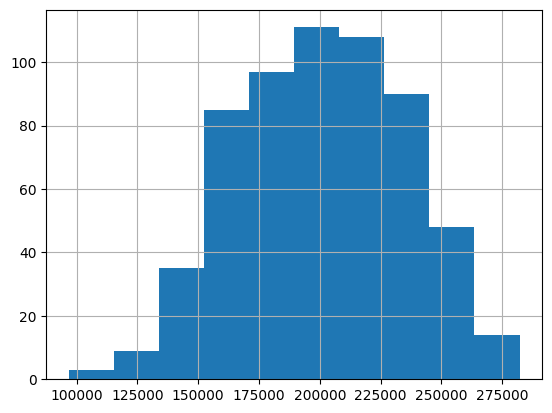

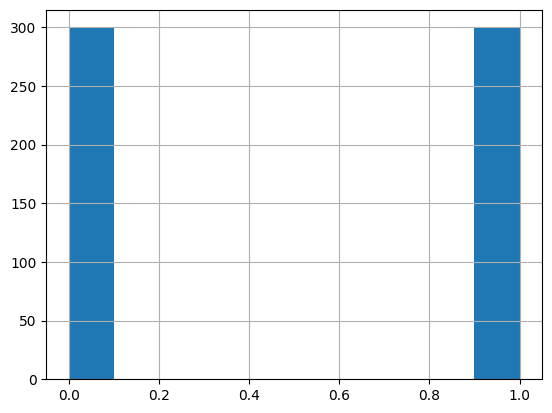

In [5]:
print(f"Median= {np.median(df["price"])}")
print(df.describe())

plt.show(df["price"].hist())
plt.show(df['high_price'].hist())

✏️ **Reflection:** What is the Python equivalent of `if_else()`?

**Answer**  the equivalent of if_else() in Python is np.where()



## 4. Conceptual Warm‑Up: glm vs tidymodels

### In base R (`glm`)

```r
glm(high_price ~ size + neighborhood + type,
    data = df,
    family = binomial)
```

* Single model object
* Inference-first
* No required train/test split

### In tidymodels

```r
log_spec <- logistic_reg() %>%
  set_engine("glm") %>%
  set_mode("classification")

log_fit <- fit(log_spec,
               high_price ~ size + neighborhood + type,
               data = train)
```

* Workflow-first
* Explicit resampling
* Metrics-based evaluation

✏️ **Key idea:** Python separates these workflows into *different libraries*.

---

## 5. Exploratory Analysis

Median price: 201165


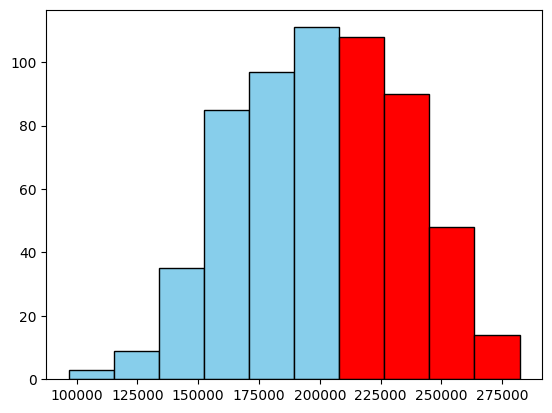

In [6]:
# TODO: Create a histogram of price, colored by high_price

# 1. Calculate the median of the column
median_price = df['price'].median()
print(f"Median price: {median_price:.0f}")

# 2. Plot the histogram and get the bar patches
# N: count in each bin, bins: bin edges, patches: the bar objects
N, bins, patches = plt.hist(df['price'], edgecolor='black', color='grey') #bins=20

# 4. Iterate over the bars (patches) and color them based on the condition
for patch, bin_center in zip(patches, bins[:-1]):
    # Check if the bin's range (or center) is above the median.
    if bin_center > median_price:
        patch.set_facecolor('red') # Color bars above median in red
    else:
        patch.set_facecolor('skyblue') # Color bars below median in skyblue


✏️ **Reflection:** What would separation look like in this plot?

---

## 6. Logistic Regression with statsmodels (R glm → Python)

### R Reference

```r
model_r <- glm(high_price ~ size + neighborhood + type,
               data = df,
               family = binomial)
summary(model_r)
```

### Python Translation


In [7]:
# TODO: Fit a logistic regression using statsmodels
model_sm = smf.logit(formula="high_price ~ size + neighborhood + type", data=df).fit()


Optimization terminated successfully.
         Current function value: 0.686263
         Iterations 4


In [8]:
# TODO: Display the model summary
print(model_sm.summary())



                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  547
Model:                          Logit   Df Residuals:                      538
Method:                           MLE   Df Model:                            8
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                0.009929
Time:                        23:34:58   Log-Likelihood:                -375.39
converged:                       True   LL-Null:                       -379.15
Covariance Type:            nonrobust   LLR p-value:                    0.4807
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.1847      0.287      0.644      0.520      -0.378       0.747
neighborhood[T.Midtown]       -0.3162      0.275     -1.148      0.251      -0.856 

✏️ **Reflection:** Identify two similarities between `summary(model_r)` and `model_sm.summary()`.

---

## 7. Odds Ratios

### R

```r
exp(coef(model_r))
```

### Python

In [9]:
# TODO: Compute odds ratios from the statsmodels output
odds_ratios = model_sm.params.apply(np.exp)
odds_ratios

,0
Intercept,1.202818
neighborhood[T.Midtown],0.728933
neighborhood[T.Suburb],1.130512
neighborhood[T.Uptown],0.994232
neighborhood[T.Waterfront],1.515414
type[T.MultiFamily],1.163808
type[T.SingleFamily],1.144190
type[T.Townhouse],1.297211
size,0.999818



✏️ **Interpretation:** What does an odds ratio greater than 1 mean?

---

## 8. Predicted Probabilities

In [10]:
# TODO: Add predicted probabilities to the DataFrame
df["pred_prob"] = model_sm.predict(df)
df.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price,pred_prob
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0,0.582896
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0,0.514464
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0,0.426782
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0,0.431537
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0,0.527525


(array([ 5., 10., 20., 23., 26., 19., 23., 30., 42., 65., 69., 59., 44.,
        43., 23., 17., 12.,  7.,  6.,  4.]),
 array([0.35443935, 0.36918351, 0.38392766, 0.39867182, 0.41341597,
        0.42816013, 0.44290428, 0.45764844, 0.47239259, 0.48713674,
        0.5018809 , 0.51662505, 0.53136921, 0.54611336, 0.56085752,
        0.57560167, 0.59034582, 0.60508998, 0.61983413, 0.63457829,
        0.64932244]),
 <BarContainer object of 20 artists>)

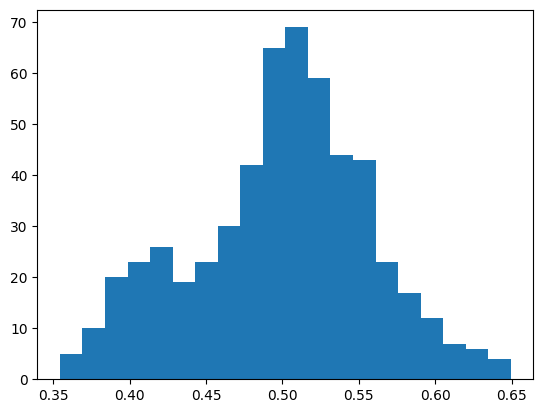

In [11]:
# TODO: Plot the distribution of predicted probabilities
plt.hist(df["pred_prob"], bins=20)

✏️ **Reflection:** Why are probabilities more informative than hard class labels?

---

## 9. Logistic Regression with scikit‑learn (tidymodels → Python)

### tidymodels analogy

* `initial_split()` → `train_test_split()`
* `fit()` → `.fit()`
* `predict(type = "prob")` → `.predict_proba()`

### Python Workflow


In [24]:
df.isna().sum()  # 76 NaNs
df[df.isna().any(axis=1)]
df[df.isna().any(axis=1)]

,listing_id,price,size,bedrooms,neighborhood,type,high_price,pred_prob
5,100006,143269.0,1763.208584,4.000000,Waterfront,SingleFamily,0,NaN
38,100039,141224.0,1763.208584,3.000000,Midtown,SingleFamily,0,NaN
63,100064,168864.0,1763.208584,2.000000,Suburb,Condo,0,NaN
101,100102,172489.0,1763.208584,2.000000,Suburb,Townhouse,0,NaN
105,100106,156414.0,1763.208584,4.000000,Suburb,SingleFamily,0,NaN
111,100112,184739.0,1763.208584,1.000000,Midtown,SingleFamily,0,NaN
118,100119,211211.0,1763.208584,1.000000,Uptown,SingleFamily,1,NaN
124,100125,215957.0,1763.208584,3.000000,Downtown,Condo,1,NaN
125,100126,184001.0,1763.208584,3.000000,Uptown,Condo,0,NaN
136,100137,165942.0,1763.208584,2.000000,Waterfront,Condo,0,NaN


In [22]:


# drop NaN

df.isna().sum()  # 76 NaNs
df[df.isna().any(axis=1)]
df[df.isna().any(axis=1)]df["size"] = df["size"].fillna(df["size"].mean())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].mean())



# Dealing with CATEGORICAL variables# Since "neighborhood" is categorical, I have to
# replace it with n dummy variables (n=number of levels - 1).
## A simple way to generate dummy variables is pandas get_dummies. per below.

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=["listing_id", "price","bedrooms", "high_price"])
y = df_encoded["high_price"]

# TODO: Create X and y
# X = df[["size", "neighborhood", "type"]]
# y = df["high_price"]

# TODO: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# TODO: Fit a scikit-learn logistic regression model
model_sk = LogisticRegression()
model_sk.fit(X_train, y_train)



SyntaxError: invalid syntax (4095721156.py, line 5)

In [ ]:
# TODO: Generate class predictions and predicted probabilities
y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)[:, 1]


## 10. Model Evaluation


In [ ]:
# TODO: Compute accuracy

In [ ]:
# TODO: Compute confusion matrix

In [ ]:
# TODO: Plot ROC curve and compute AUC

✏️ **Reflection:** Why might AUC be preferred over accuracy?

---

## 11. Comparison Table (Fill In)

| Feature          | R (glm) | R (tidymodels) | statsmodels | scikit‑learn |
| ---------------- | ------- | -------------- | ----------- | ------------ |
| Primary goal     |         |                |             |              |
| Uses formulas    |         |                |             |              |
| Train/test split |         |                |             |              |
| Output           |         |                |             |              |

## 12. Active Learning (15–20 minutes)

**Pair activity:**

1. One student explains logistic regression *using odds*, not probabilities
2. The other explains the difference between statsmodels and scikit‑learn
3. Together, decide which tool you would use for:

   * Policy analysis
   * Price prediction

Be prepared to justify your choices.

## 13. Takeaways

* Logistic regression is the *same model* in R and Python
* Differences are about **workflow and goals**, not mathematics
* statsmodels ≈ `glm`
* scikit‑learn ≈ `tidymodels`
